# Stage 6: Model Training: Multi-Class Gradient Boosting

## Objective
Train an XGBoost multi-class probabilistic classifier on the 
prepared DMatrix artifacts from Notebook 05.

## What this notebook produces
- A trained XGBoost model (`artifacts/xgboost_model.json`)
- A training config record (`artifacts/training_config.json`)
- MLflow run with all hyperparameters and metrics logged
- Feature importance chart for model interpretability

## Why XGBoost with multi:softprob
The Santander problem is a 24-class recommendation task. 
`multi:softprob` forces the model to output a full probability 
distribution across all 24 product classes for every customer 
not a single hard prediction. This lets the Flask API rank all 
24 products by probability and return the top-5 recommendations 
with confidence scores.

## Key design decisions
- `num_class=24` — fixed at 24 even though only 21 classes are 
  active. XGBoost requires this to match the product catalogue size.
- `eval_metric=mlogloss` — multi-class log loss, stable for 
  probability calibration across imbalanced classes.
- `early_stopping_rounds=15` — stops training if val loss does 
  not improve for 15 consecutive rounds, preventing overfitting.
- Sample weights embedded in dtrain handles the 9852x imbalance.

##  Environment and Load Artifacts

Load the DMatrix files and labels saved by Notebook 05.
All training runs against pre-built DMatrix no raw data processing here.

In [2]:
# core imports
import xgboost as xgb
import numpy as np
import json
import os
import mlflow
import mlflow.xgboost
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Load DMatrix artifacts from Notebook 05
dtrain = xgb.DMatrix('../artifacts/dtrain.buffer')
dval   = xgb.DMatrix('../artifacts/dval.buffer')

# Load labels for post-training evaluation
y_train = np.load('../artifacts/y_train.npy')
y_val   = np.load('../artifacts/y_val.npy')

print(f"dtrain : {dtrain.num_row():,} rows × {dtrain.num_col()} features")
print(f"dval   : {dval.num_row():,} rows × {dval.num_col()} features")
print(f"Unique train classes : {len(np.unique(y_train))}")
print(f"Unique val classes   : {len(np.unique(y_val))}")
print("\nArtifacts loaded. Ready for training.")

dtrain : 27,096 rows × 69 features
dval   : 6,774 rows × 69 features
Unique train classes : 21
Unique val classes   : 18

Artifacts loaded. Ready for training.


## Step 2: Define Hyperparameters

These hyperparameters are based on the best-known configuration 
for the Santander competition dataset, validated across published 
Kaggle solution writeups.

Key parameters explained:
- `eta=0.05` — learning rate. Low value means more trees needed 
  but better generalisation. Paired with early stopping so we 
  never over-iterate.
- `max_depth=6` — maximum tree depth. Controls model complexity. 
  6 is the standard for tabular recommendation tasks.
- `subsample=0.9` — each tree sees 90% of training rows randomly. 
  Reduces overfitting on dominant classes.
- `colsample_bytree=0.9` — each tree sees 90% of features randomly. 
  Forces the model to discover diverse feature combinations.
- `num_class=24` — fixed at full product catalogue size. Do not 
  change this even though only 21 classes are active in training.
- `seed=42` — reproducibility across all runs.

In [3]:
# Define XGBoost hyperparameters
params = {
    # Core objective: output full softmax probability vector per customer
    'objective':        'multi:softprob',
    'num_class':        24,            # full product catalogue, never change

    # Tree architecture
    'max_depth':        6,             # standard depth for tabular recsys
    'eta':              0.05,          # learning rate low for better generalisation
    'subsample':        0.9,           # row sampling per tree reduces overfitting
    'colsample_bytree': 0.9,           # feature sampling per tree

    # Evaluation
    'eval_metric':      'mlogloss',    # multi-class log loss  probability calibration

    # Reproducibility and performance
    'seed':             42,
    'nthread':          -1,            # use all available CPU cores
    'verbosity':        1,             # show warnings only
}

NUM_BOOST_ROUNDS    = 500   # maximum trees early stopping will cut this short
EARLY_STOPPING      = 15    # stop if val loss does not improve for 15 rounds

print("Hyperparameters defined:")
# Displaying the hyperparameters in a clear format helps us verify 
# that we are using the intended settings before starting the training process. 
# It also serves as a reference for tuning and experimentation later on.
for k, v in params.items():
    print(f"  {k:<22} : {v}")
print(f"\n  num_boost_round      : {NUM_BOOST_ROUNDS}")
print(f"  early_stopping_rounds: {EARLY_STOPPING}")

Hyperparameters defined:
  objective              : multi:softprob
  num_class              : 24
  max_depth              : 6
  eta                    : 0.05
  subsample              : 0.9
  colsample_bytree       : 0.9
  eval_metric            : mlogloss
  seed                   : 42
  nthread                : -1
  verbosity              : 1

  num_boost_round      : 500
  early_stopping_rounds: 15


## Train the Model

Training loop with watchlist monitoring the model evaluates 
against both train and val at every boosting round and prints 
the log loss for each. Early stopping halts training automatically 
when val loss stops improving.

Expected training time on CPU: 15–40 minutes depending on how 
many rounds early stopping allows before halting.
Do not interrupt this cell once running.

In [4]:
# Watchlist monitor both train and val loss at every round
watchlist = [
    (dtrain, 'train'),
    (dval,   'val')
]

print("Starting XGBoost training...")
print(f"Max rounds: {NUM_BOOST_ROUNDS} | Early stopping: {EARLY_STOPPING} rounds")
print("-" * 60)

# Train with MLflow autologging
with mlflow.start_run(run_name="xgboost_training_nb06"):

    # Log all hyperparameters to MLflow
    mlflow.log_params(params)
    mlflow.log_param("num_boost_rounds",     NUM_BOOST_ROUNDS)
    mlflow.log_param("early_stopping_rounds", EARLY_STOPPING)

    # Train the model
    evals_result = {}   # will store train/val loss per round for plotting

    model = xgb.train(
        params           = params,
        dtrain           = dtrain,
        num_boost_round  = NUM_BOOST_ROUNDS,
        evals            = watchlist,
        early_stopping_rounds = EARLY_STOPPING,
        evals_result     = evals_result,
        verbose_eval     = 25,   # print loss every 25 rounds
    )

    # Log final metrics
    best_round    = model.best_iteration
    best_val_loss = model.best_score

    mlflow.log_metric("best_iteration",       best_round)
    mlflow.log_metric("best_val_mlogloss",    best_val_loss)

print("-" * 60)
print(f"Training complete.")
print(f"Best iteration  : {best_round}")
print(f"Best val logloss: {best_val_loss:.6f}")

Starting XGBoost training...
Max rounds: 500 | Early stopping: 15 rounds
------------------------------------------------------------


2026/05/22 11:26:55 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/05/22 11:26:56 INFO mlflow.store.db.utils: Updating database tables


[0]	train-mlogloss:2.86782	val-mlogloss:3.00799
[25]	train-mlogloss:1.26264	val-mlogloss:1.83062
[50]	train-mlogloss:0.87861	val-mlogloss:1.52582
[75]	train-mlogloss:0.70645	val-mlogloss:1.38904
[100]	train-mlogloss:0.60954	val-mlogloss:1.31556
[125]	train-mlogloss:0.54747	val-mlogloss:1.27032
[150]	train-mlogloss:0.50238	val-mlogloss:1.23763
[175]	train-mlogloss:0.46914	val-mlogloss:1.21486
[200]	train-mlogloss:0.44233	val-mlogloss:1.19768
[225]	train-mlogloss:0.41924	val-mlogloss:1.18408
[250]	train-mlogloss:0.39899	val-mlogloss:1.17336
[275]	train-mlogloss:0.38175	val-mlogloss:1.16479
[300]	train-mlogloss:0.36683	val-mlogloss:1.15862
[325]	train-mlogloss:0.35330	val-mlogloss:1.15315
[350]	train-mlogloss:0.34156	val-mlogloss:1.14889
[375]	train-mlogloss:0.33050	val-mlogloss:1.14477
[400]	train-mlogloss:0.32083	val-mlogloss:1.14170
[425]	train-mlogloss:0.31181	val-mlogloss:1.14050
[450]	train-mlogloss:0.30384	val-mlogloss:1.13945
[475]	train-mlogloss:0.29594	val-mlogloss:1.13839
[491]

## Plot Training and Validation Loss Curves

Visualise how train and val log loss evolved across boosting rounds.

What to look for:
- Both curves decreasing together = healthy learning
- Val loss flattening while train loss keeps dropping = overfitting
- Early stopping fired = the dotted vertical line shows where 
  training halted to prevent overfitting

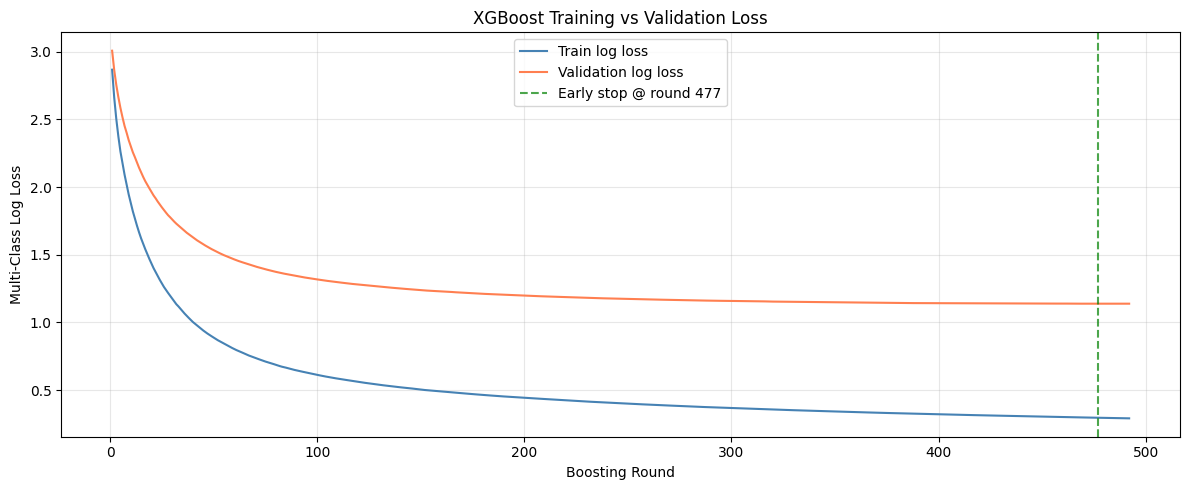

Loss curve saved → artifacts/loss_curve.png


In [5]:
# Plot training and validation loss curves
# Visualising the training and validation loss curves helps us understand how the model is learning over time.
# We can see if the model is overfitting (train loss much lower than val loss) or
# underfitting (both losses high and not improving).
train_loss = evals_result['train']['mlogloss']
val_loss   = evals_result['val']['mlogloss']
rounds     = range(1, len(train_loss) + 1)
# The vertical dashed line indicates the round where early stopping fired, 
# which is the point of best generalisation on the validation set.
plt.figure(figsize=(12, 5))
plt.plot(rounds, train_loss, label='Train log loss',      color='steelblue')
plt.plot(rounds, val_loss,   label='Validation log loss', color='coral')

# Mark the best iteration where early stopping fired
plt.axvline(
    x=best_round + 1,
    color='green', linestyle='--', alpha=0.7,
    label=f'Early stop @ round {best_round + 1}'
)

# Final plot aesthetics
# Adding labels, title, legend, and grid for better readability of the loss curves.
plt.xlabel('Boosting Round')
plt.ylabel('Multi-Class Log Loss')
plt.title('XGBoost Training vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../artifacts/loss_curve.png', dpi=150)
plt.show()

print(f"Loss curve saved → artifacts/loss_curve.png")


## Feature Importance

XGBoost computes feature importance as the number of times each 
feature is used to split a tree node across all boosting rounds 
(gain-based importance).

High-importance features are the strongest predictors of which 
product a customer will add next. We expect lag features 
(previous product ownership) to dominate  a customer who already 
holds a savings account is much more likely to add an investment 
fund than a customer who holds nothing.

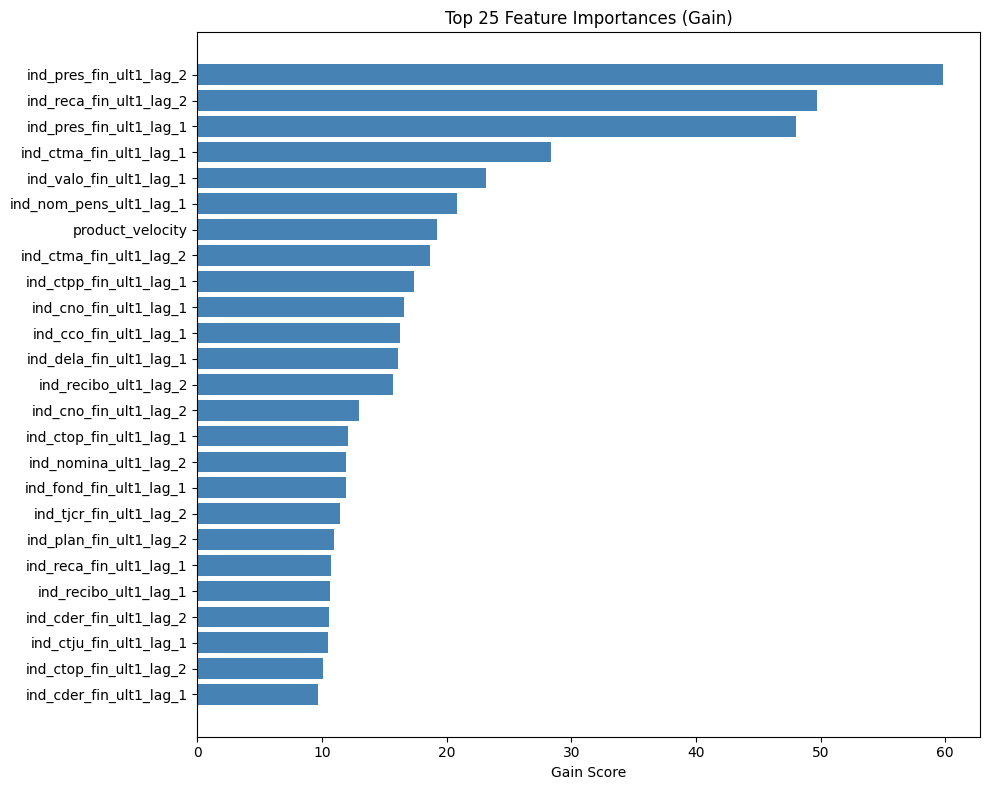

Top 10 features:
  ind_pres_fin_ult1_lag_2                  : 59.81
  ind_reca_fin_ult1_lag_2                  : 49.69
  ind_pres_fin_ult1_lag_1                  : 48.01
  ind_ctma_fin_ult1_lag_1                  : 28.36
  ind_valo_fin_ult1_lag_1                  : 23.15
  ind_nom_pens_ult1_lag_1                  : 20.81
  product_velocity                         : 19.19
  ind_ctma_fin_ult1_lag_2                  : 18.67
  ind_ctpp_fin_ult1_lag_1                  : 17.34
  ind_cno_fin_ult1_lag_1                   : 16.60

Feature importance chart saved → artifacts/feature_importance.png


In [6]:
import joblib

# Get feature importance scores (by gain most informative split metric)
importance = model.get_score(importance_type='gain')

# Load feature column names for readable labels
feature_cols = joblib.load('../artifacts/feature_cols.pkl')

# Sort by importance descending and take top 25
importance_series = (
    sorted(importance.items(), key=lambda x: x[1], reverse=True)[:25]
)
# Separate names and scores for plotting
feat_names  = [x[0] for x in importance_series]
feat_scores = [x[1] for x in importance_series]

# Plot horizontal bar chart of top 25 features
plt.figure(figsize=(10, 8))
plt.barh(feat_names[::-1], feat_scores[::-1], color='steelblue')
plt.xlabel('Gain Score')
plt.title('Top 25 Feature Importances (Gain)')
plt.tight_layout()
plt.savefig('../artifacts/feature_importance.png', dpi=150)
plt.show()

print("Top 10 features:")
# Printing the top 10 features and their importance scores in a clear format allows 
# us to quickly identify which features are most influential in the model's predictions. 
# This insight can guide future feature engineering efforts and help us understand the model's decision-making process.
for name, score in importance_series[:10]:
    print(f"  {name:<40} : {score:.2f}")

print(f"\nFeature importance chart saved → artifacts/feature_importance.png")

## Quick MAP@7 Sanity Check

Run a quick MAP@7 computation on the validation set immediately 
after training to confirm the model is producing ranked predictions 
and not outputting random noise.

Full evaluation with the complete metric dashboard happens in 
Notebook 07. This is just a training-complete sanity check.

In [7]:
# Custom MAP@7 evaluation function
def mapk(actual, predicted, k=7):
    """Compute Mean Average Precision at K."""
    # The MAP@K metric evaluates the quality of the top-K predictions by comparing them to the actual purchased product.
    # It rewards correct predictions that appear higher in the list, 
    # which is crucial for a recommender system where the order of recommendations matters.
    def apk(a, p, k):
        if not a:
            return 0.0
        # Only consider top-K predictions for scoring
        p = p[:k]
        score, hits = 0.0, 0
        # Iterate through the predicted list and calculate precision at each hit
        for i, pred in enumerate(p):
            if pred in a and pred not in p[:i]:
                # When a correct prediction is found (pred in actual) and it hasn't been counted before (not in p[:i]),
                # we increment the hit count and add to the score based on the position of the hit in the predicted list.
                hits += 1
                score += hits / (i + 1)
                # This means that if the first prediction is correct, it contributes 1.0 to the score (1 hit / position 1).
                # If the second prediction is correct, it contributes 0.5 (2 hits / position 2), and so on. 
                # This way, correct predictions that appear earlier in the list have
        return score / min(len(a), k)
    return np.mean([apk([a], p, k) for a, p in zip(actual, predicted)])

# Generate predictions on validation set
raw_preds  = model.predict(dval)                               # shape (N, 24)
top7_preds = np.argsort(raw_preds, axis=1)[:, ::-1][:, :7]   # top-7 per customer

map7 = mapk(y_val.tolist(), top7_preds.tolist(), k=7)

print(f"MAP@7 (validation) : {map7:.6f}")
print(f"Target threshold   : ≥ 0.028")
print(f"Status : {'Meets baseline' if map7 >= 0.028 else 'Below baseline proceed to NB07 for full diagnostics'}")

# Log to MLflow
mlflow.log_metric("map_at_7_sanity", map7)

MAP@7 (validation) : 0.699674
Target threshold   : ≥ 0.028
Status : Meets baseline


##  Save Model and Training Config

Save the trained model and a config file recording exactly which 
hyperparameters produced this result. The config file is used by 
the Flask API at boot time to confirm it is loading the correct 
model version.

In [8]:
# Save trained model
MODEL_PATH = '../artifacts/xgboost_model.json'
model.save_model(MODEL_PATH)

# Save training config for Flask verification and audit trail
config = {
    "model_path"           : MODEL_PATH,
    "best_iteration"       : int(best_round),
    "best_val_mlogloss"    : float(best_val_loss),
    "map_at_7_sanity"      : float(map7),
    "num_class"            : 24,
    "active_classes"       : int(len(np.unique(y_train))),
    "train_rows"           : int(dtrain.num_row()),
    "val_rows"             : int(dval.num_row()),
    "feature_count"        : int(dtrain.num_col()),
    "hyperparameters"      : params,
    "num_boost_rounds_used": int(best_round + 1),
}

CONFIG_PATH = '../artifacts/training_config.json'
with open(CONFIG_PATH, 'w') as f:
    json.dump(config, f, indent=2)

print(f"Model saved  → {MODEL_PATH}")
print(f"Config saved → {CONFIG_PATH}")
print(f"\nNotebook 06 complete. Ready for Stage 7: Evaluation.")

Model saved  → ../artifacts/xgboost_model.json
Config saved → ../artifacts/training_config.json

Notebook 06 complete. Ready for Stage 7: Evaluation.
